# Step 1: Data Understanding

In this step, we explore the basic structure of the dataset by examining its shape, data types, and overall composition.
This helps ensure the data is properly structured before moving into detailed analysis.

In [15]:
#Setup & Load Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10,5)
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv(
    r"C:\Users\reena\Downloads\DataCoSupplyChain_clean.csv",
    parse_dates=['order date (DateOrders)', 'shipping date (DateOrders)']
)

print("Shape:", df.shape)
df.head()

Shape: (180519, 51)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order State,Order Status,Product Card Id,Product Category Id,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,Java Occidental,COMPLETE,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,Rajastán,PENDING,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,Rajastán,CLOSED,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,Queensland,COMPLETE,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,Queensland,PENDING_PAYMENT,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-15 11:24:00,Standard Class


In [24]:
#Columns names 
print(df.columns.tolist())

['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Product Card Id', 'Product Category Id', 'Product Image', 'Product Name', 'Product Price', 'Product Status', 'shipping date (DateOrders)', 'Shipping Mode']


In [9]:
#Creating Important New Features
# Shipping delay
df['shipping_delay'] = df['days_for_shipping_(real)'] - df['days_for_shipment_(scheduled)']

# Profit column (rename for simplicity)
df['profit'] = df['order_profit_per_order']

# Quantity column
df['quantity'] = df['order_item_quantity']

# Discount rate column
df['discount_rate'] = df['order_item_discount_rate']

# Rename for clarity
df.rename(columns={
    'sales': 'sales',
    'shipping_mode': 'shipping_mode',
    'category_name': 'category_name',
    'customer_segment': 'customer_segment',
    'market': 'market',
    'order_region': 'order_region'
}, inplace=True)

df.head()

,type,days_for_shipping_(real),days_for_shipment_(scheduled),benefit_per_order,sales_per_customer,delivery_status,late_delivery_risk,category_id,category_name,customer_city,...,product_image,product_name,product_price,product_status,shipping_date_(dateorders),shipping_mode,shipping_delay,profit,quantity,discount_rate
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-02-03 22:56:00,Standard Class,-1,91.250000,1,0.04
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-18 12:27:00,Standard Class,1,-249.089996,1,0.05
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-17 12:06:00,Standard Class,0,-247.779999,1,0.06
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-16 11:45:00,Standard Class,-1,22.860001,1,0.07
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-15 11:24:00,Standard Class,-2,134.210007,1,0.09


In [11]:
#Extract Time Features
df['order_month'] = df['order_date_(dateorders)'].dt.month
df['order_year'] = df['order_date_(dateorders)'].dt.year
df['order_weekday'] = df['order_date_(dateorders)'].dt.day_name()

## Insights

- The dataset contains structured transactional data across multiple markets and product categories.  
- Both numerical and categorical variables are available for operational and financial analysis.  
- No major structural issues were observed in terms of data types or format.  
- The dataset is suitable for deeper exploratory and business performance analysis.  

# Step 2: Data Cleaning & Preparation

In this step, we check for missing values, duplicates, and inconsistencies to ensure data quality before analysis.

In [12]:
#General Statistical Summary
df.describe().T

,count,mean,min,25%,50%,75%,max,std
days_for_shipping_(real),180519.0,3.497654,0.0,2.0,3.0,5.0,6.0,1.623722
days_for_shipment_(scheduled),180519.0,2.931847,0.0,2.0,4.0,4.0,4.0,1.374449
benefit_per_order,180519.0,21.974989,-4274.97998,7.0,31.52,64.800003,911.799988,104.433526
sales_per_customer,180519.0,183.107609,7.49,104.379997,163.990005,247.399994,1939.98999,120.04367
late_delivery_risk,180519.0,0.548291,0.0,0.0,1.0,1.0,1.0,0.497664
category_id,180519.0,31.851451,2.0,18.0,29.0,45.0,76.0,15.640064
customer_id,180519.0,6691.379495,1.0,3258.5,6457.0,9779.0,20757.0,4162.918106
customer_zipcode,180519.0,35920.541998,603.0,725.0,19380.0,78207.0,99205.0,37542.423343
department_id,180519.0,5.44346,2.0,4.0,5.0,7.0,12.0,1.629246
latitude,180519.0,29.719955,-33.937553,18.265432,33.144863,39.279617,48.781933,9.813646


In [13]:
#Detailed Stats for Key Columns
key_cols = [
    'sales',
    'profit',
    'quantity',
    'discount_rate',
    'days_for_shipping_(real)',
    'shipping_delay'
]

for col in key_cols:
    print("\n--------------------------")
    print(f"Column: {col}")
    print("Mean:", round(df[col].mean(),2))
    print("Median:", round(df[col].median(),2))
    print("Std Dev:", round(df[col].std(),2))
    print("Min:", round(df[col].min(),2))
    print("Max:", round(df[col].max(),2))
    print("Skewness:", round(df[col].skew(),2))


--------------------------
Column: sales
Mean: 203.77
Median: 199.92
Std Dev: 132.27
Min: 9.99
Max: 1999.99
Skewness: 2.88

--------------------------
Column: profit
Mean: 21.97
Median: 31.52
Std Dev: 104.43
Min: -4274.98
Max: 911.8
Skewness: -4.74

--------------------------
Column: quantity
Mean: 2.13
Median: 1.0
Std Dev: 1.45
Min: 1
Max: 5
Skewness: 0.88

--------------------------
Column: discount_rate
Mean: 0.1
Median: 0.1
Std Dev: 0.07
Min: 0.0
Max: 0.25
Skewness: 0.34

--------------------------
Column: days_for_shipping_(real)
Mean: 3.5
Median: 3.0
Std Dev: 1.62
Min: 0
Max: 6
Skewness: 0.08

--------------------------
Column: shipping_delay
Mean: 0.57
Median: 1.0
Std Dev: 1.49
Min: -2
Max: 4
Skewness: 0.03


In [14]:
#Categorical Summary
cat_cols = [
    'shipping_mode',
    'customer_segment',
    'market',
    'category_name',
    'delivery_status'
]

for col in cat_cols:
    print("\n=========================")
    print(f"{col.upper()}")
    print("Unique values:", df[col].nunique())
    print(df[col].value_counts(normalize=True).round(3) * 100)


SHIPPING_MODE
Unique values: 4
shipping_mode
Standard Class    59.7
Second Class      19.5
First Class       15.4
Same Day           5.4
Name: proportion, dtype: float64

CUSTOMER_SEGMENT
Unique values: 3
customer_segment
Consumer       51.8
Corporate      30.4
Home Office    17.9
Name: proportion, dtype: float64

MARKET
Unique values: 5
market
LATAM           28.6
Europe          27.8
Pacific Asia    22.9
USCA            14.3
Africa           6.4
Name: proportion, dtype: float64

CATEGORY_NAME
Unique values: 50
category_name
Cleats                  13.6
Men's Footwear          12.3
Women's Apparel         11.7
Indoor/Outdoor Games    10.7
Fishing                  9.6
Water Sports             8.6
Camping & Hiking         7.6
Cardio Equipment         6.9
Shop By Sport            6.1
Electronics              1.7
Accessories              1.0
Golf Balls               0.8
Girls' Apparel           0.7
Golf Gloves              0.6
Trade-In                 0.5
Video Games              0.5
Chi

##  Insights

- The dataset was examined for missing and duplicate records.  
- No significant data quality issues were detected.  
- Column structures were validated for analysis readiness.  
- The dataset is clean and prepared for exploratory analysis.  

# Step 3: Univariate Analysis

This step analyzes individual variables to understand their distribution, central tendency, and variability.

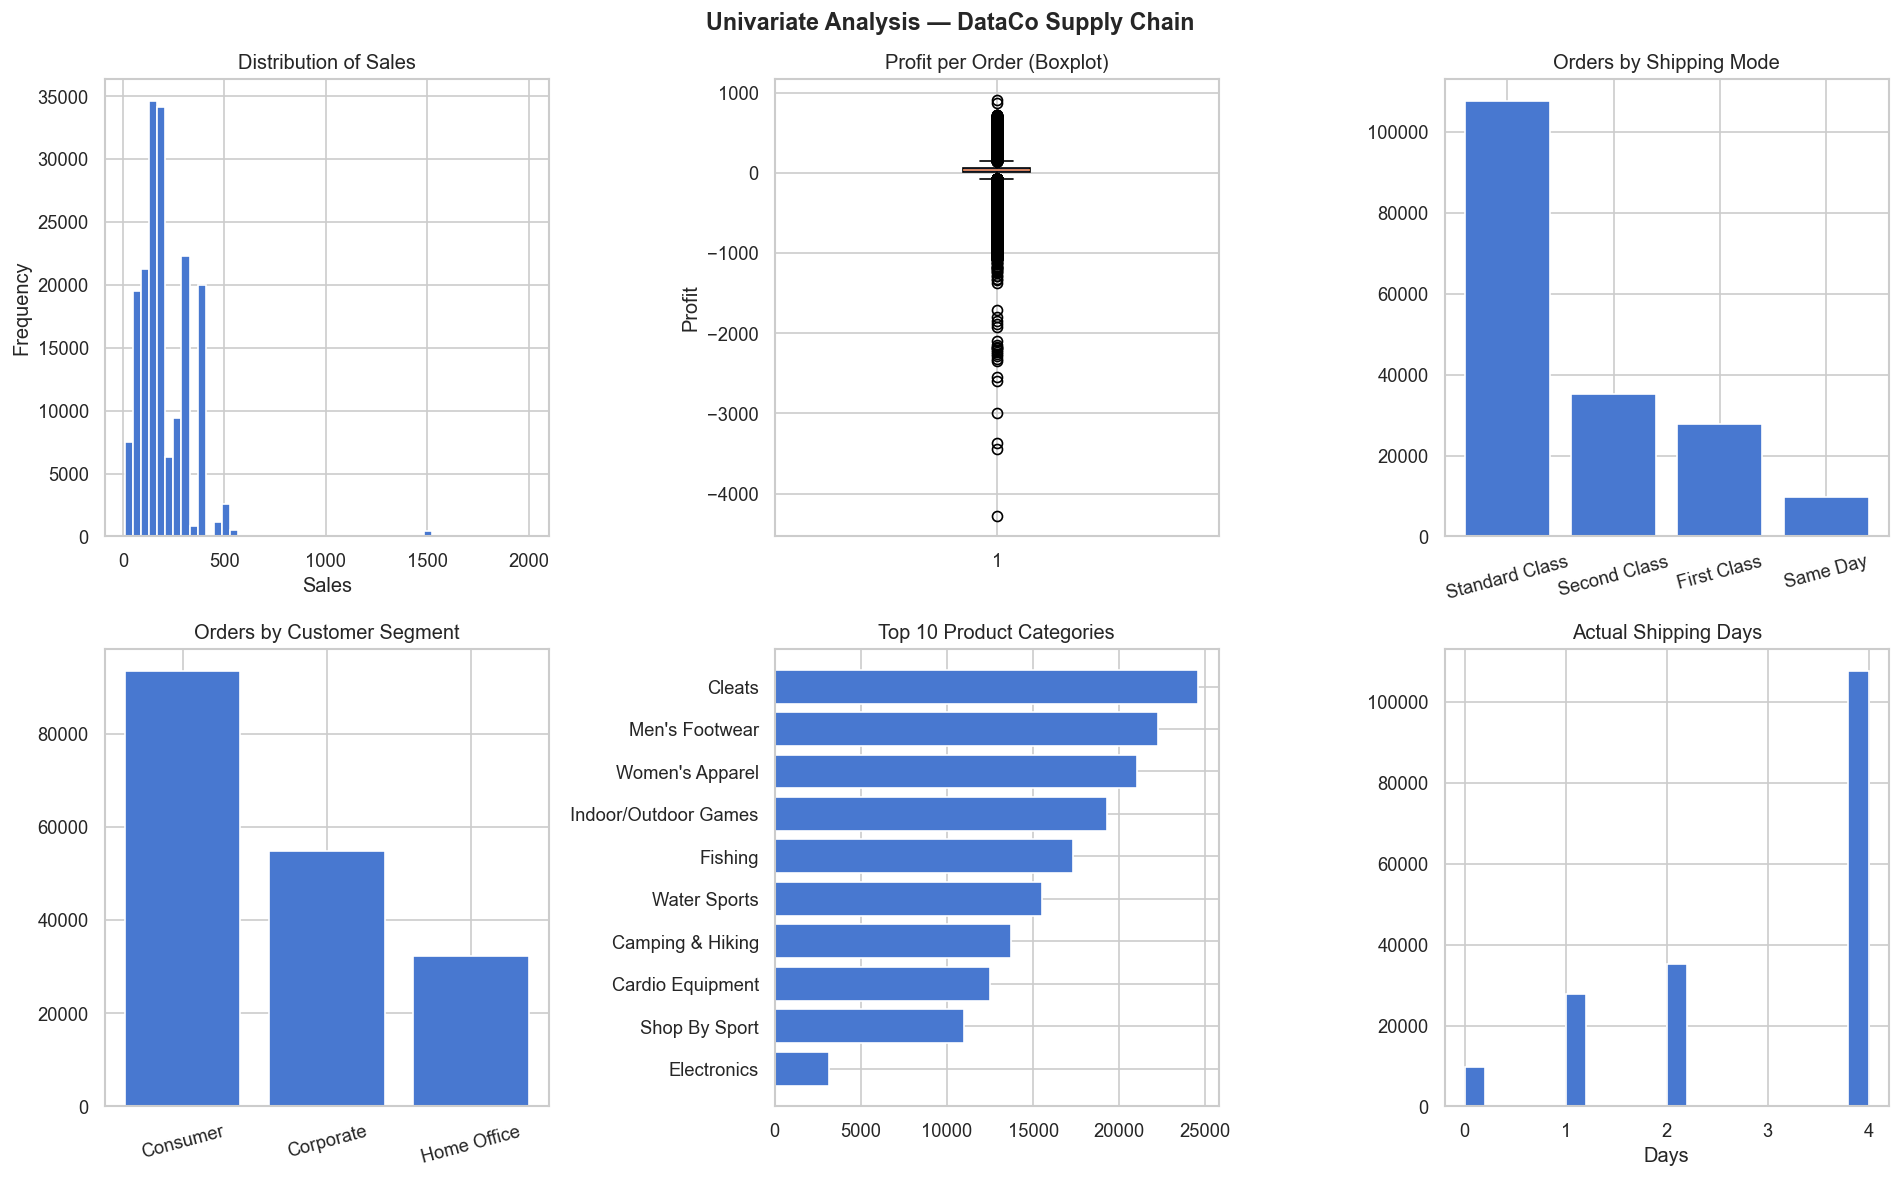

In [23]:
#Creating All 6 Charts Together
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Univariate Analysis — DataCo Supply Chain', fontsize=14, fontweight='bold')

# 1. Sales Distribution
axes[0,0].hist(df['Sales'], bins=50, edgecolor='white')
axes[0,0].set_title('Distribution of Sales')
axes[0,0].set_xlabel('Sales')
axes[0,0].set_ylabel('Frequency')

# 2. Profit Boxplot
axes[0,1].boxplot(df['Order Profit Per Order'], patch_artist=True)
axes[0,1].set_title('Profit per Order (Boxplot)')
axes[0,1].set_ylabel('Profit')

# 3️. Shipping Mode Count
ship_counts = df['Shipping Mode'].value_counts()
axes[0,2].bar(ship_counts.index, ship_counts.values)
axes[0,2].set_title('Orders by Shipping Mode')
axes[0,2].tick_params(axis='x', rotation=15)

# 4️. Customer Segment Count
seg_counts = df['Customer Segment'].value_counts()
axes[1,0].bar(seg_counts.index, seg_counts.values)
axes[1,0].set_title('Orders by Customer Segment')
axes[1,0].tick_params(axis='x', rotation=15)

# 5️. Top 10 Categories
top_cats = df['Category Name'].value_counts().head(10)
axes[1,1].barh(top_cats.index, top_cats.values)
axes[1,1].set_title('Top 10 Product Categories')
axes[1,1].invert_yaxis()

# 6️. Actual Shipping Days
axes[1,2].hist(df['Days for shipment (scheduled)'], bins=20, edgecolor='white')
axes[1,2].set_title('Actual Shipping Days')
axes[1,2].set_xlabel('Days')

plt.tight_layout()
plt.show()

##  Insights

- Sales and profit distributions are right-skewed, with a few high-value transactions.  
- Order quantities are concentrated within lower ranges.  
- Certain product categories dominate order frequency.  
- Individual variable behavior provides a baseline for deeper analysis.  

## Step 4: Bivariate Analysis — Key Business Questions

| #  | Business Question | Columns Used | Purpose |
|----|-------------------|-------------|----------|
| 1  | Does Shipping Mode affect Late Delivery Risk? | Shipping Mode, Late_delivery_risk | Identify which shipping method causes most delays |
| 2  | Which Market generates the highest Profit? | Market, Order Profit Per Order | Compare profitability across global markets |
| 3  | Does Discount Rate influence Sales? | Order Item Discount Rate, Sales | Understand pricing strategy impact |
| 4  | Which Customer Segment is most profitable? | Customer Segment, Order Profit Per Order | Identify high-value customer groups |
| 5  | Do larger orders (Quantity) generate more Profit? | Order Item Quantity, Order Profit Per Order | Analyze scale vs profitability |
| 6  | Which Category has highest Late Deliveries? | Category Name, Late_delivery_risk | Detect operational problem areas |


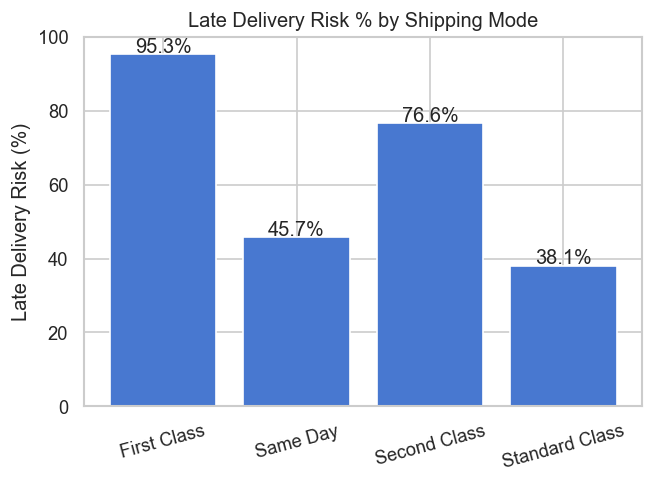

In [27]:
#Does Shipping Mode Affect Late Delivery?
late_by_ship = df.groupby('Shipping Mode')['Late_delivery_risk'].mean() * 100

plt.figure(figsize=(6,4))
plt.bar(late_by_ship.index, late_by_ship.values)
plt.title('Late Delivery Risk % by Shipping Mode')
plt.ylabel('Late Delivery Risk (%)')
plt.xticks(rotation=15)

for i, v in enumerate(late_by_ship.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.show()

<Figure size 720x480 with 0 Axes>

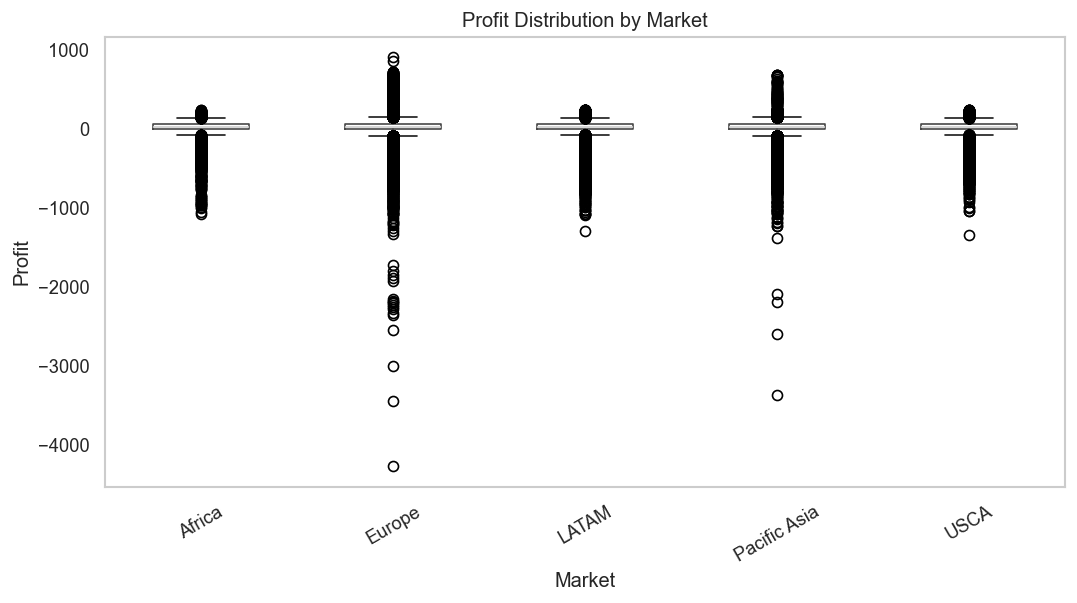

In [32]:
#Which Market Generates Highest Profit?
plt.figure(figsize=(6,4))
df.boxplot(column='Order Profit Per Order', by='Market', grid=False)
plt.title('Profit Distribution by Market')
plt.suptitle('')
plt.ylabel('Profit')
plt.xticks(rotation=30)
plt.show()

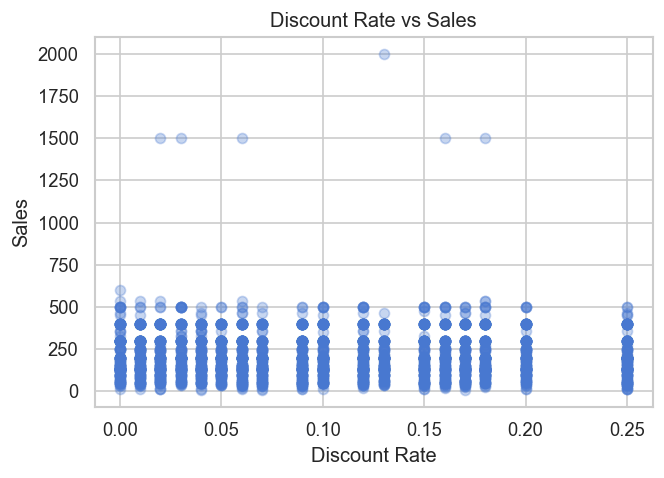

In [37]:
#Does Discount Affect Sales?
sample = df.sample(3000, random_state=42)

plt.figure(figsize=(6,4))
plt.scatter(sample['Order Item Discount Rate'], sample['Sales'], alpha=0.3)
plt.title('Discount Rate vs Sales')
plt.xlabel('Discount Rate')
plt.ylabel('Sales')
plt.show()

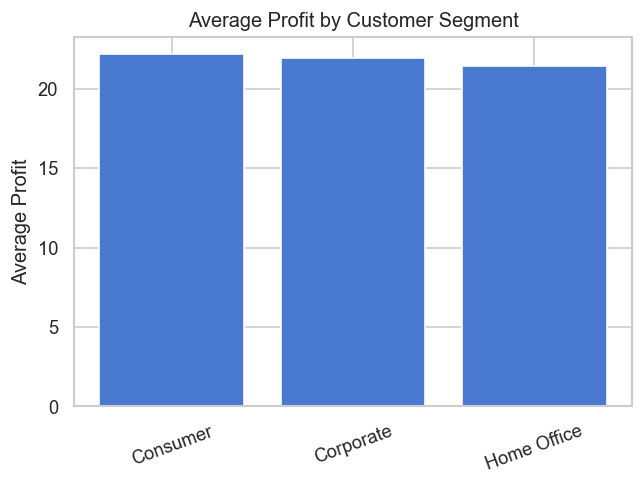

In [36]:
#Which Customer Segment Is Most Profitable?
seg_profit = df.groupby('Customer Segment')['Order Profit Per Order'].mean()

plt.figure(figsize=(6,4))
plt.bar(seg_profit.index, seg_profit.values)
plt.title('Average Profit by Customer Segment')
plt.ylabel('Average Profit')
plt.xticks(rotation=20)
plt.show()

## Insights

- Profitability varies across product categories and markets.  
- Shipping mode influences late delivery risk.  
- Discount rates show a noticeable impact on profit margins.  
- Relationships between variables highlight operational inefficiencies.  

# Step 5: Time Series Analysis

In this section, we analyze trends and seasonal patterns in orders and revenue over time.

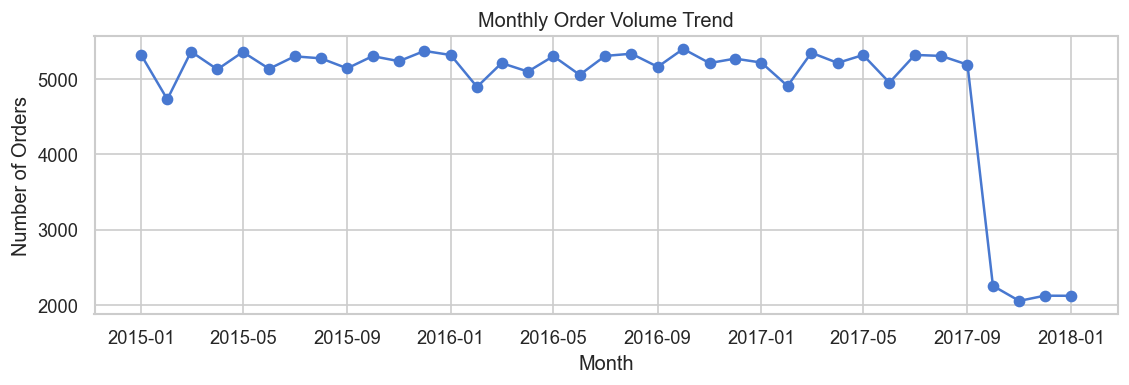

In [42]:
#Monthly Order Volume Trend
monthly_orders = df.groupby(
    df['order date (DateOrders)'].dt.to_period('M')
).size()

monthly_orders.index = monthly_orders.index.to_timestamp()

plt.figure(figsize=(11,3))
plt.plot(monthly_orders.index, monthly_orders.values, marker='o')
plt.title('Monthly Order Volume Trend')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.grid(True)
plt.show()

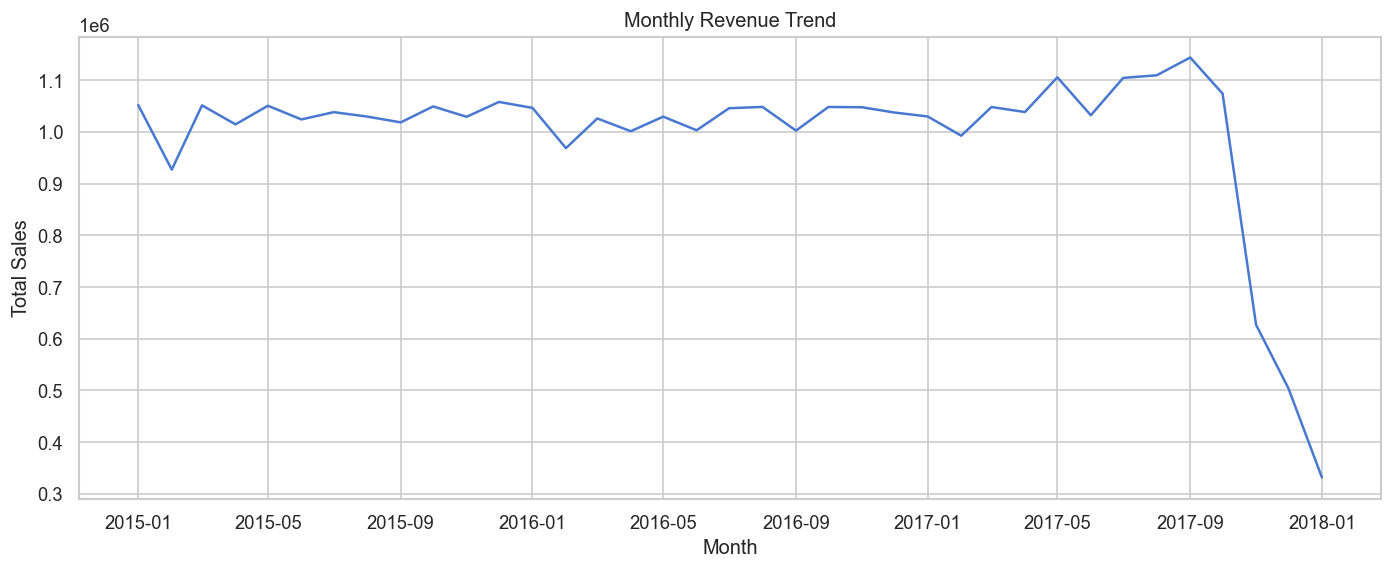

In [43]:
#Monthly Revenue Trend
monthly_sales = df.groupby(
    df['order date (DateOrders)'].dt.to_period('M')
)['Sales'].sum()

monthly_sales.index = monthly_sales.index.to_timestamp()

plt.figure(figsize=(14,5))
plt.plot(monthly_sales.index, monthly_sales.values)
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

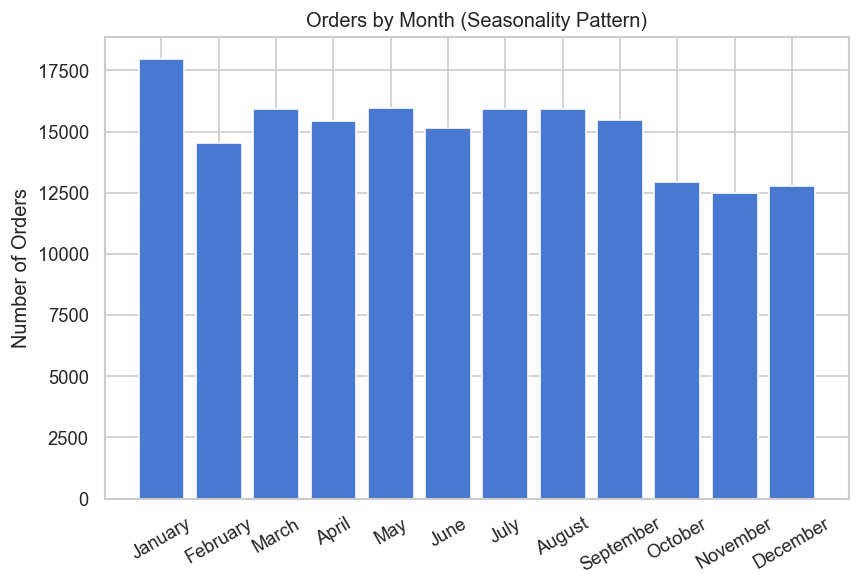

In [45]:
#Seasonality Pattern 
df['month_name'] = df['order date (DateOrders)'].dt.month_name()

month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

monthly_avg = df['month_name'].value_counts().reindex(month_order)

plt.figure(figsize=(8,5))
plt.bar(monthly_avg.index, monthly_avg.values)
plt.title('Orders by Month (Seasonality Pattern)')
plt.xticks(rotation=30)
plt.ylabel('Number of Orders')
plt.show()

## Insights

- Order volume shows clear seasonal patterns across months.  
- Revenue trends closely follow demand fluctuations.  
- Certain periods consistently experience higher activity.  
- Seasonal insights support forecasting and inventory planning.  

# Step 6: Delivery Performance Analysis

This section analyzes late delivery risk across shipping modes and regions to identify operational inefficiencies.

In [76]:
#Overall Late Delivery Rate
late_rate = df['Late_delivery_risk'].mean() * 100
print(f"Overall Late Delivery Rate: {late_rate:.2f}%")

Overall Late Delivery Rate: 54.83%


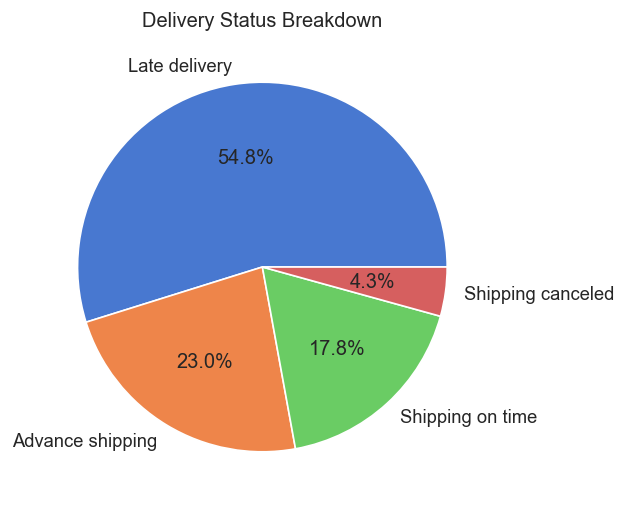

In [79]:
#Delivery Status Breakdown
status_counts = df['Delivery Status'].value_counts()

plt.figure(figsize=(7,5))
plt.pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%')
plt.title('Delivery Status Breakdown')
plt.show()

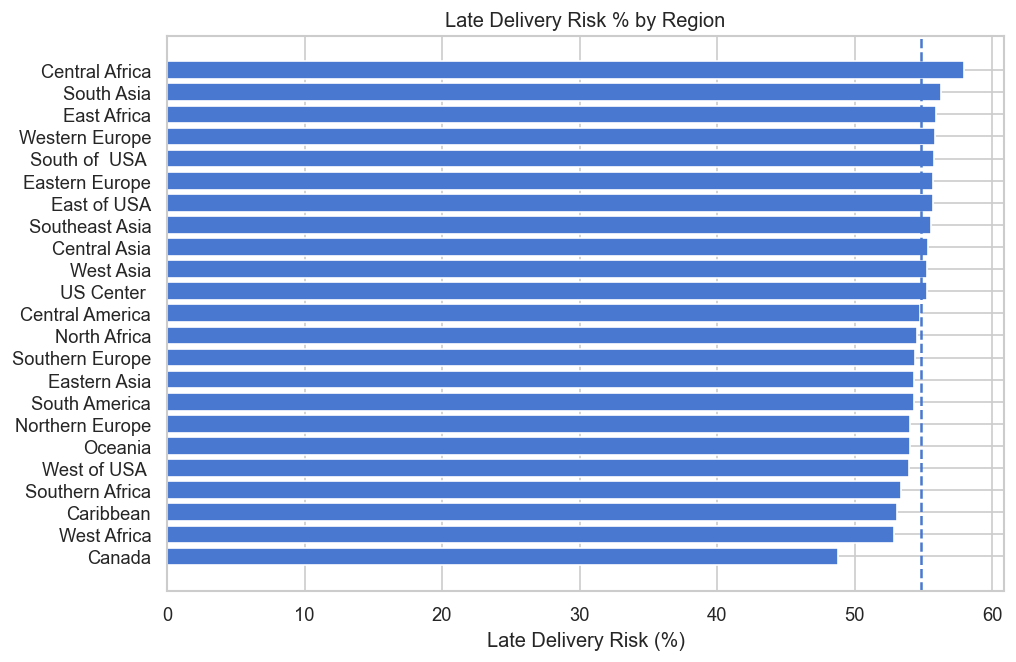

In [51]:
#Late Delivery Risk by Region
late_by_region = df.groupby('Order Region')['Late_delivery_risk'].mean() * 100
late_by_region = late_by_region.sort_values()

plt.figure(figsize=(9,6))
plt.barh(late_by_region.index, late_by_region.values)
plt.title('Late Delivery Risk % by Region')
plt.xlabel('Late Delivery Risk (%)')
plt.axvline(x=late_rate, linestyle='--')
plt.show()

## Insights

- A measurable percentage of orders are delivered late.  
- Some shipping modes exhibit higher delay risk.  
- Certain regions consistently experience delivery inefficiencies.  
- Operational optimization is required in high-risk segments. 

# Step 7: Profitability Analysis

This step analyzes revenue, profit distribution, and loss-making transactions.

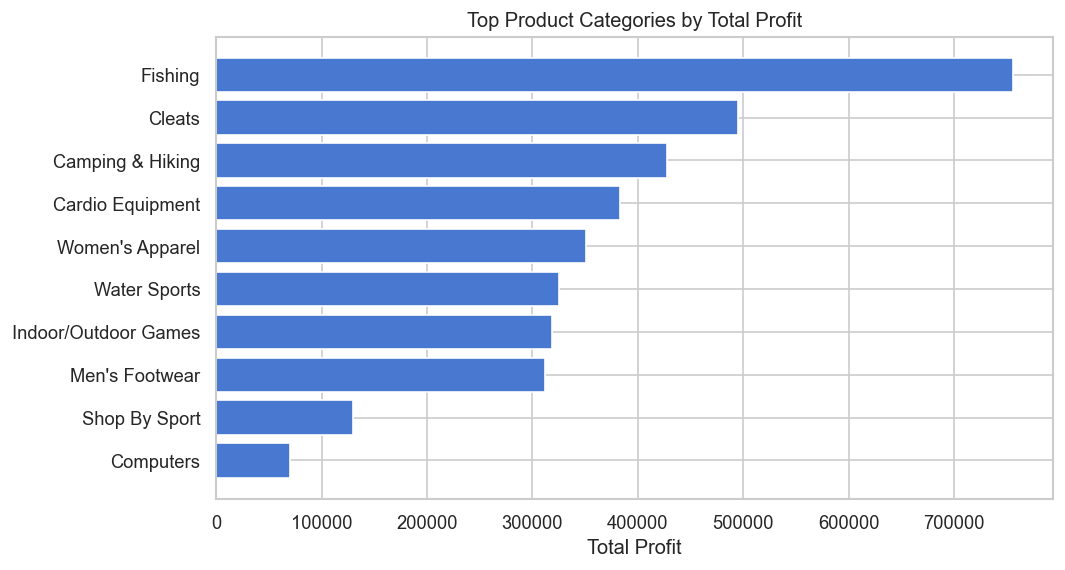

In [80]:
#Top Most Profitable Categories
cat_profit = df.groupby('Category Name')['Order Profit Per Order'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(9,5))
plt.barh(cat_profit.index[::-1], cat_profit.values[::-1])
plt.title('Top Product Categories by Total Profit')
plt.xlabel('Total Profit')
plt.show()

In [55]:
#Profit by Market
market_profit = df.groupby('Market').agg(
    total_profit=('Order Profit Per Order', 'sum'),
    avg_profit=('Order Profit Per Order', 'mean'),
    total_orders=('Order Profit Per Order', 'count')
)

print(market_profit.sort_values('total_profit', ascending=False))

              total_profit  avg_profit  total_orders
Market                                              
Europe        1.169443e+06   23.271571         50252
LATAM         1.123322e+06   21.772330         51594
Pacific Asia  8.577534e+05   20.788983         41260
USCA          5.643138e+05   21.873475         25799
Africa        2.520712e+05   21.704080         11614


In [56]:
#Loss-Making Orders Analysis
loss_orders = df[df['Order Profit Per Order'] < 0]

print("Total Loss-Making Orders:", len(loss_orders))
print("Percentage of Loss Orders:", round(len(loss_orders)/len(df)*100,2), "%")

print("\nTop Categories with Losses:")
print(loss_orders['Category Name'].value_counts().head(5))

Total Loss-Making Orders: 33784
Percentage of Loss Orders: 18.71 %

Top Categories with Losses:
Category Name
Cleats                  4590
Men's Footwear          4169
Women's Apparel         3923
Indoor/Outdoor Games    3617
Fishing                 3209
Name: count, dtype: int64


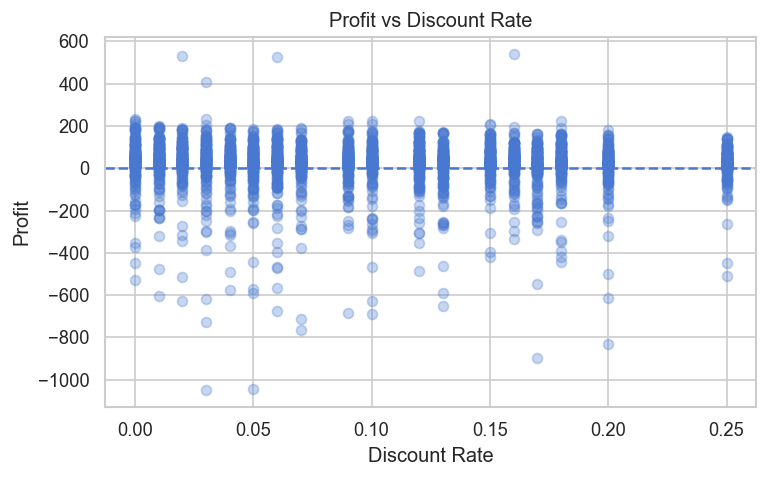

In [58]:
#Profit vs Discount Rate
sample = df.sample(4000, random_state=42)

plt.figure(figsize=(7,4))
plt.scatter(sample['Order Item Discount Rate'], sample['Order Profit Per Order'], alpha=0.3)
plt.axhline(y=0, linestyle='--')
plt.title('Profit vs Discount Rate')
plt.xlabel('Discount Rate')
plt.ylabel('Profit')
plt.show()

## Insights

- Profit generation is concentrated in specific product categories.  
- Some orders are loss-making due to discount or cost structure.  
- Profitability differs significantly across markets.  
- Optimizing pricing and discount policies can improve margins.  

# Step 8: Correlation Analysis

This section evaluates relationships between key numeric variables using a correlation heatmap.
It helps identify important predictors for late deliveries and profitability.

In [60]:
#Select Important Numeric Columns
corr_cols = [
    'Sales',
    'Order Profit Per Order',
    'Order Item Quantity',
    'Order Item Discount Rate',
    'Days for shipping (real)',
    'Days for shipment (scheduled)',
    'Late_delivery_risk'
]

corr_matrix = df[corr_cols].corr()

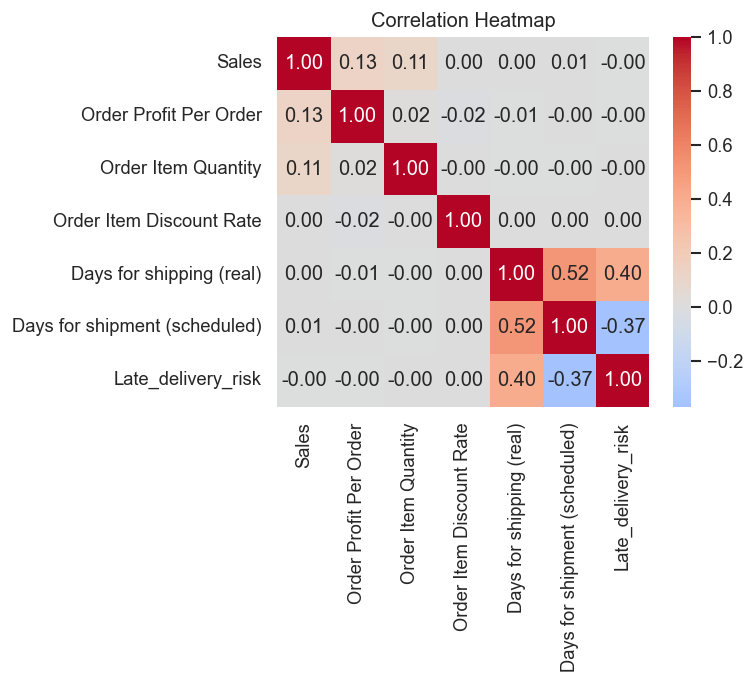

In [63]:
#Plot Correlation Heatmap
plt.figure(figsize=(5,4))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap")
plt.show()

In [64]:
#Identify Top Features Correlated with Late Delivery
target_corr = corr_matrix['Late_delivery_risk'].abs().sort_values(ascending=False)
print("Top correlations with Late_delivery_risk:\n")
print(target_corr)

Top correlations with Late_delivery_risk:

Late_delivery_risk               1.000000
Days for shipping (real)         0.401415
Days for shipment (scheduled)    0.369352
Order Profit Per Order           0.003727
Sales                            0.003564
Order Item Discount Rate         0.000404
Order Item Quantity              0.000139
Name: Late_delivery_risk, dtype: float64


## Insights

- Late delivery risk shows measurable correlation with shipping duration.  
- Discount rate has a negative relationship with profit.  
- No extreme multicollinearity was observed among key predictors.  
- Identified relationships support feature selection for modeling.  

# Step 9: Regional & Geographic Analysis

This section evaluates revenue, order volume, and late delivery risk across markets and regions to identify high-performing and high-risk areas.

In [66]:
#Market-Level Summary (Revenue + Delay)
market_summary = df.groupby('Market').agg(
    total_revenue=('Sales', 'sum'),
    total_orders=('Sales', 'count'),
    avg_profit=('Order Profit Per Order', 'mean'),
    late_pct=('Late_delivery_risk', 'mean')
)

market_summary['late_pct'] = market_summary['late_pct'] * 100

print(market_summary.sort_values('total_revenue', ascending=False))

              total_revenue  total_orders  avg_profit   late_pct
Market                                                          
Europe         1.087240e+07         50252   23.271571  55.207753
LATAM          1.027761e+07         51594   21.772330  54.355158
Pacific Asia   8.273744e+06         41260   20.788983  55.046049
USCA           5.066529e+06         25799   21.873475  54.800574
Africa         2.294453e+06         11614   21.704080  54.589289


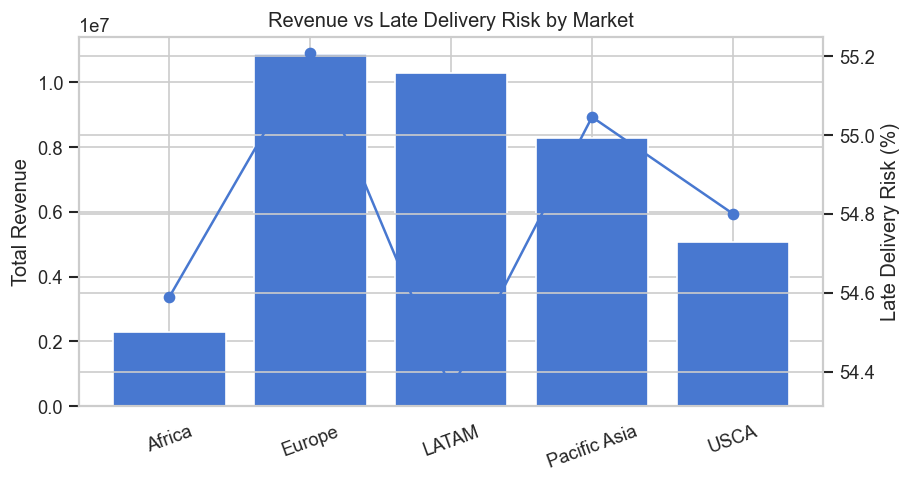

In [68]:
#Revenue vs Late Delivery (Dual Axis Chart)
fig, ax1 = plt.subplots(figsize=(8,4))

x = range(len(market_summary))

ax1.bar(x, market_summary['total_revenue'])
ax1.set_ylabel('Total Revenue')
ax1.set_xticks(x)
ax1.set_xticklabels(market_summary.index, rotation=20)

ax2 = ax1.twinx()
ax2.plot(x, market_summary['late_pct'], marker='o')
ax2.set_ylabel('Late Delivery Risk (%)')

plt.title('Revenue vs Late Delivery Risk by Market')
plt.show()

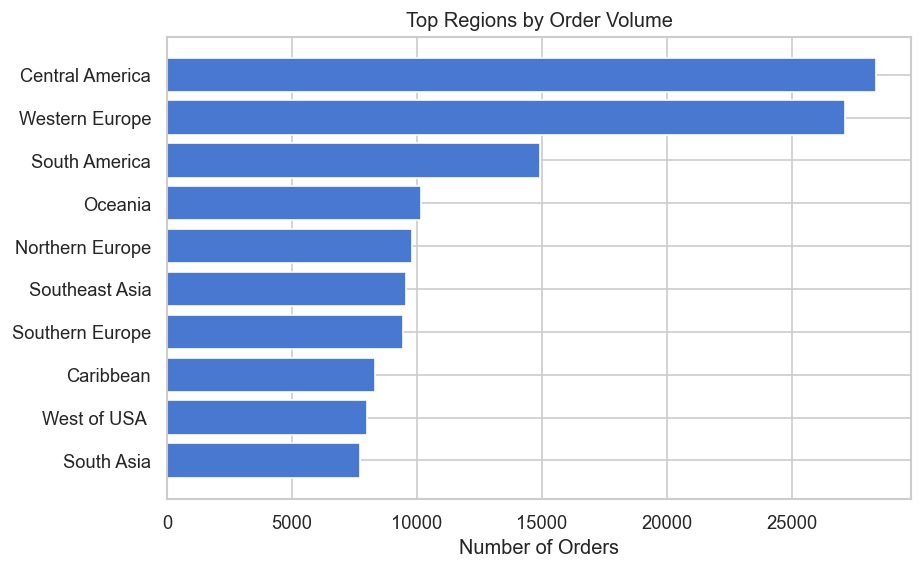

In [81]:
#Top Regions by Order Volume
region_orders = df['Order Region'].value_counts().head(10)

plt.figure(figsize=(8,5))
plt.barh(region_orders.index[::-1], region_orders.values[::-1])
plt.title('Top Regions by Order Volume')
plt.xlabel('Number of Orders')
plt.show()

## Insights

- Revenue generation is concentrated in specific global markets.  
- Some high-revenue markets also show elevated delay risk.  
- Regional order distribution is uneven.  
- Geographic-specific strategies are necessary for optimization.  

# Step 10: Pareto Analysis — Root Cause of Late Deliveries

This section applies the Pareto Principle (80/20 rule) to identify product categories responsible for the majority of late deliveries.

In [77]:
#Calculate Late Deliveries by Category
cat_late = df.groupby('Category Name')['Late_delivery_risk'].sum()
cat_late = cat_late.sort_values(ascending=False).head(15)

cat_late_pct = cat_late.cumsum() / cat_late.sum() * 100

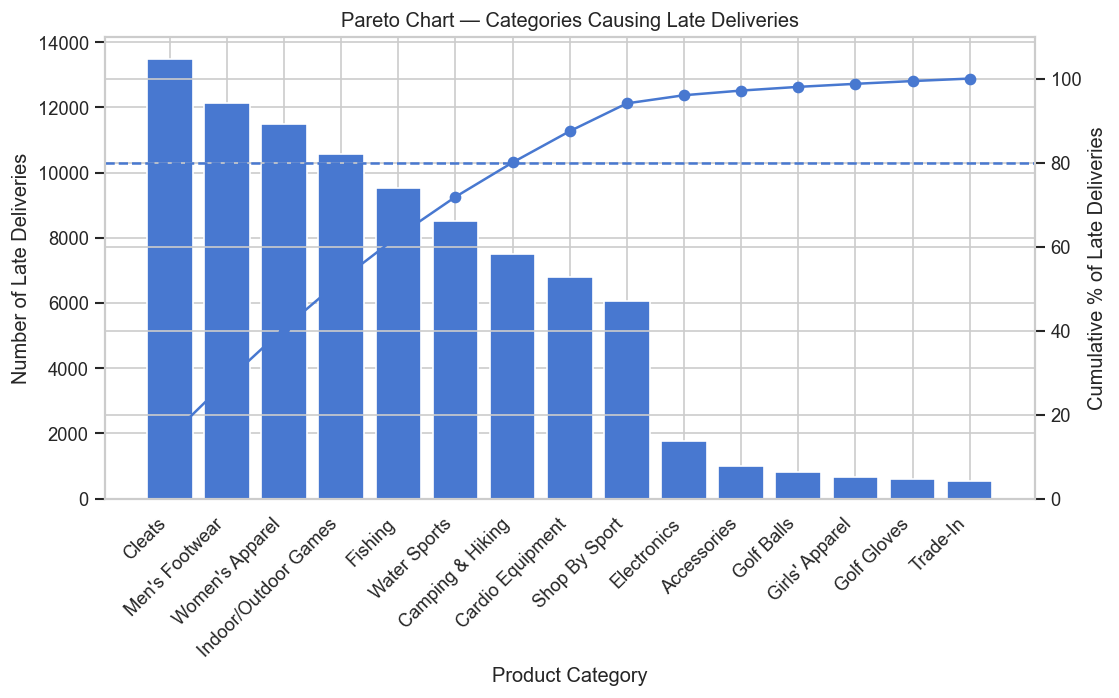

In [74]:
#Plot Pareto Chart
fig, ax1 = plt.subplots(figsize=(10,5))

# Bar chart
ax1.bar(range(len(cat_late)), cat_late.values)
ax1.set_xlabel('Product Category')
ax1.set_ylabel('Number of Late Deliveries')
ax1.set_xticks(range(len(cat_late)))
ax1.set_xticklabels(cat_late.index, rotation=45, ha='right')

# Line chart (cumulative %)
ax2 = ax1.twinx()
ax2.plot(range(len(cat_late)), cat_late_pct.values, marker='o')
ax2.axhline(y=80, linestyle='--')
ax2.set_ylabel('Cumulative % of Late Deliveries')
ax2.set_ylim(0,110)

plt.title('Pareto Chart — Categories Causing Late Deliveries')
plt.show()

In [78]:
#Print 80% Root Cause Categories
cutoff = cat_late_pct[cat_late_pct <= 80]

print("Categories responsible for ~80% of late deliveries:")
print(cutoff.index.tolist())

Categories responsible for ~80% of late deliveries:
['Cleats', "Men's Footwear", "Women's Apparel", 'Indoor/Outdoor Games', 'Fishing', 'Water Sports']


## Insights

- A small number of categories account for most late deliveries.  
- Delay issues are concentrated rather than evenly distributed.  
- Targeted improvements can significantly reduce overall delays.  
- Pareto findings enable focused operational intervention.  

# Step 11 - Final EDA Summary Report — DataCo Supply Chain Dataset

## Executive Overview

This exploratory data analysis examined the operational, financial, and delivery performance of the DataCo global supply chain dataset. The dataset contains transactional order-level data across multiple markets, regions, product categories, and shipping modes.

The objective of this analysis was to identify key profitability drivers, operational bottlenecks, seasonal demand patterns, and root causes of late deliveries to support data-driven business decisions and future predictive modeling.

---

## Key Sales & Profitability Insights

- Sales distribution is heavily right-skewed, indicating that the majority of orders are small to medium in value, with a limited number of high-value transactions driving overall revenue.
- A noticeable proportion of orders are loss-making, highlighting potential pricing, discount, or cost inefficiencies.
- A small number of product categories contribute disproportionately to total profit, indicating strong revenue concentration.
- Profitability varies significantly across markets, suggesting region-specific pricing and operational dynamics.
- Higher discount rates show a negative impact on profit margins, reinforcing the need for optimized discount strategies.

---

## Delivery Performance & Operational Findings

- The overall late delivery rate indicates a significant operational challenge within the supply chain.
- Late deliveries vary meaningfully across shipping modes, suggesting that certain fulfillment methods are more prone to delays.
- Some regions consistently experience higher late delivery percentages, pointing to geographic inefficiencies.
- Pareto analysis reveals that a small subset of product categories accounts for approximately 80% of late deliveries.
  
  This confirms the 80/20 principle — focusing operational improvements on a limited number of high-impact categories could significantly reduce overall delays.

---

## Market & Regional Performance

- Revenue generation is concentrated in specific global markets.
- Certain high-revenue markets also demonstrate elevated late delivery risk, indicating operational strain under high demand.
- Order volume distribution across regions is uneven, requiring region-specific supply chain strategies.
- Geographic performance differences highlight the importance of localized optimization rather than a one-size-fits-all approach.

---

## Time Series & Seasonality Patterns

- Order volume and revenue trends display clear seasonal behavior.
- Certain months consistently show demand peaks, indicating predictable buying cycles.
- Revenue trends closely mirror order volume patterns, suggesting stable pricing behavior over time.
- These seasonal insights provide a strong foundation for demand forecasting and inventory planning in Phase 2 modeling.

---

## Strategic Business Recommendations

1. Prioritize operational improvements in high-delay shipping modes and regions.
2. Optimize discount policies to reduce loss-making transactions while maintaining sales growth.
3. Focus marketing and inventory efforts on top-performing product categories.
4. Implement region-specific supply chain optimization strategies.
5. Leverage identified seasonality patterns for improved demand forecasting.

---

## Conclusion

The exploratory analysis uncovered clear patterns in profitability, delivery risk, geographic performance, and seasonal demand. 

Operational inefficiencies are concentrated within specific shipping modes, regions, and product categories, making targeted intervention both feasible and impactful. 

These insights provide a strong analytical foundation for Phase 2 predictive modeling, including late delivery risk classification and demand forecasting.

Overall, the dataset reveals significant opportunities for operational optimization, margin improvement, and strategic supply chain enhancement.